# Tutorial #7: Perturbational Data

# Using scFO to visualize treatment effects in scRNA-seq data

In this tutorial, we will run differential expression in scFO-factor space between treatment and control groups and visualize the results. For this, we will use the ex vivo slice culture GBM dataset of >300,000 single cells. See Tutorial #3 for projecting scFO onto this data. 

Note: in previous tutorials, we projected gene-level differential expression signatures for each treatment/cell type (derived from standard DESeq-2) as an `ontology` modality. Here, we demonstrate an alternative method to testing perturbation effects by first projecting factor scores at the single cell level, and running differential expression analysis between groups. This is more akin to using a pre-existing ontology object on new data from an experiment or clinical trial.

# Import packages

In [1]:
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import muon as mu
import re
import gseapy as gp
import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import scfo
import warnings
# Scanpy rank_genes_groups log2 warning
warnings.filterwarnings(
    "ignore",
    message=".*invalid value encountered in log2.*",
    category=RuntimeWarning,
)
# Scanpy scatter/UMAP colormap warning
warnings.filterwarnings(
    "ignore",
    message=".*No data for colormapping provided via 'c'.*",
    category=UserWarning,
)

# Running differential expression using the scFO helper

Since we have already projected factor scores onto the slice culture data, we will construct a dummy `AnnData` object that has only metadata and enrichment scores for easier memory/loading.

In [2]:
scores = pd.read_csv('val_Slice_ontology_enrichment.csv', index_col = 0)
scores.index = scores.index.astype(str)
ann = pd.read_csv('val_Slice_ingested_classifications.csv', index_col = 0)
ann.index = ann.index.astype(str)
umap = pd.read_csv('Slice_umap.csv', index_col = 0)
umap.index = umap.index.astype(str)
obs = pd.read_csv('Slice_obs.csv', index_col = 0)
obs.index = obs.index.astype(str)

adata_slice = ad.AnnData(scores.copy())
adata_slice.obs = obs.loc[adata_slice.obs.index].copy()
adata_slice.obs['classification'] = ann.loc[adata_slice.obs.index].copy()
adata_slice.obsm['ontology_scores'] = scores.loc[adata_slice.obs.index].copy()
adata_slice.obsm['X_umap'] = umap.loc[adata_slice.obs.index].values

adata_slice

AnnData object with n_obs × n_vars = 314209 × 25
    obs: 'Cell_type', 'Sequencing_Name', 'TissueID', 'Treatment', 'patient', 'cluster', 'location', 'study', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden', 'classification'
    obsm: 'ontology_scores', 'X_umap'

Let's take a look at the UMAP:

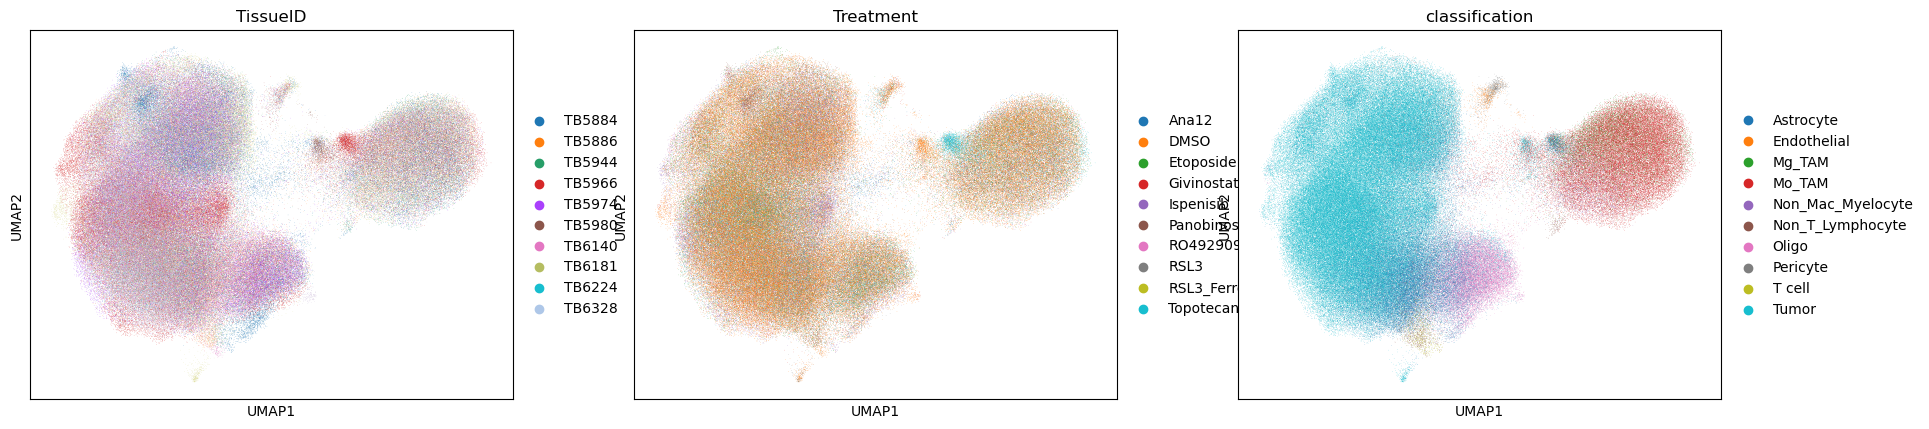

In [3]:
sc.pl.umap(adata_slice, color = ['TissueID', 'Treatment', 'classification'], cmap = 'tab20')

Let's see what cell types we have across treatments/patients:

In [4]:
adata_slice.obs.groupby(['TissueID', 'Treatment']).classification.value_counts().unstack()

classification         Astrocyte  Endothelial  Mg_TAM  Mo_TAM  \
TissueID Treatment                                              
TB5884   Ana12               942            6      32    2560   
         DMSO               1014           27      22    4555   
         Etoposide           508            5      16    1063   
         Ispenisib           205            3      29    1067   
         Panobinostat        728            4      30     970   
...                          ...          ...     ...     ...   
TB6813   DMSO                236            2       1       3   
         RSL3                 53            2       0       2   
TB6814   DMSO                232           50      84     375   
         RSL3                 73           31      35     136   
         Topotecan           463          112      26      77   

classification         Non_Mac_Myelocyte  Non_T_Lymphocyte  Oligo  Pericyte  \
TissueID Treatment                                                            
TB5884   Ana12                       347                85    353         7   
         DMSO                         34               109   2091        33   
         Etoposide                   139                28    536        30   
         Ispenisib                    78                41    178        14   
         Panobinostat                 29                15    709        18   
...                                  ...               ...    ...       ...   
TB6813   DMSO                          0                 0      3         1   
         RSL3                          0                 0      1         0   
TB6814   DMSO                         20                42      8        24   
         RSL3                         14                15      3        15   
         Topotecan                    13                 5      3        60   

classification         T cell  Tumor  
TissueID Treatment                    
TB5884   Ana12             21   1626  
         DMSO              17   9636  
         Etoposide         13   1401  
         Ispenisib         18    755  
         Panobinostat       1   4370  
...                       ...    ...  
TB6813   DMSO               0   1029  
         RSL3               0    313  
TB6814   DMSO               1    431  
         RSL3               0    138  
         Topotecan          0   2033  

[62 rows x 10 columns]

Differential expression is straightforward using the scFO `diff_exp_ontology()` helper function. This can be run in single-cell mode or in pseudo-bulk mode. We'll run differential expression between each treatment and the DMSO control, within each cell type.

In [5]:
all_de_ls = []
for ct in adata_slice.obs.classification.unique():
    try:
        _, de_results = scfo.diff_exp_ontology(
            adata_in=adata_slice,
            cell_type = ct,
            cell_type_key = 'classification',
            ontology_keys="ontology_scores",
            groupby="Treatment",
            method="wilcoxon",
            reference="DMSO",
            pseudo_bulk=True,
            pseudo_bulk_by=['TissueID', 'Treatment']
        )
        de_piv = de_results.pivot(index = 'names', columns = 'group', values = 'scores')
        de_piv.index = de_piv.index.astype(str) + '|' + ct
        all_de_ls.append(de_piv)
    except Exception as e:
        print(e)
all_de = pd.concat(all_de_ls)
all_de

Could not calculate statistics for groups Givinostat since they only contain one sample.


group,Ana12,Etoposide,Givinostat,Ispenisib,Panobinostat,RO4929097,RSL3,RSL3_Ferrostatin,Topotecan
names,,,,,,,,,
Factor0|Tumor,0.813220,1.590712,-0.486664,1.030687,1.399827,0.621874,-2.123977,-1.100239,-0.746360
Factor1|Tumor,-0.143509,1.145313,-0.567775,-0.390950,-0.381771,-0.430528,-1.115088,-0.430528,-0.390950
Factor10|Tumor,-1.195912,0.190885,-0.648886,0.533114,-2.290625,0.047836,1.168187,0.239182,-0.319868
Factor11|Tumor,-0.717547,-0.381771,0.486664,0.035541,0.827170,0.430528,0.902690,0.430528,-0.177705
Factor12|Tumor,-0.047836,0.254514,-0.243332,0.035541,-0.127257,1.004566,1.061988,-0.143509,0.248787
...,...,...,...,...,...,...,...,...,...
Factor5|Non_Mac_Myelocyte,-1.453444,0.073721,1.039402,0.330289,0.516047,2.459675,0.442326,1.966830,0.330289
Factor6|Non_Mac_Myelocyte,-0.670820,-0.737210,0.000000,-0.330289,-1.179536,-1.229837,0.294884,-1.404879,-0.330289
Factor7|Non_Mac_Myelocyte,-0.223607,0.073721,1.322876,0.000000,0.294884,1.006231,-1.843024,0.140488,-0.990867


We can add these results to our `ontology` object:

In [6]:
ontology = mu.read_h5mu('scfo_mofa_gbm.h5mu')
scfo.add_modality(
    ontology=ontology,
    modality_name = 'slice_de',
    score_df = all_de,
)

We can visualize the results across factors for a single cell type as a heat map after extracting the results dataframe with `modality_scores_to_df()`:

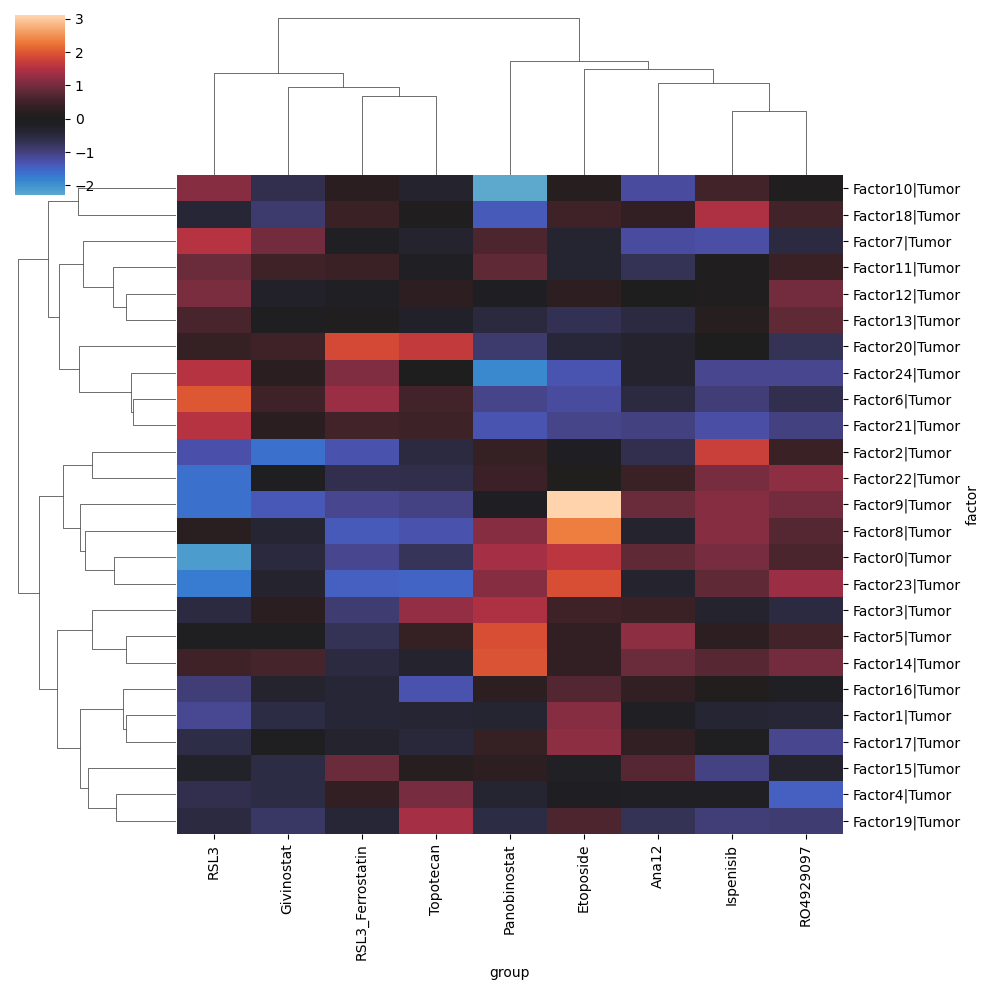

In [7]:
import seaborn as sns
sns.clustermap(
    scfo.modality_scores_to_df(
        ontology = ontology, 
        modality = 'slice_de', 
        cell_types = 'Tumor'
    ), center = 0)

Additionally, for a deeper look into treatment effects, we can plot effect sizes alongside factor weights for a given treatment/cell type using the `plot_factor_effect_sizes()` function:

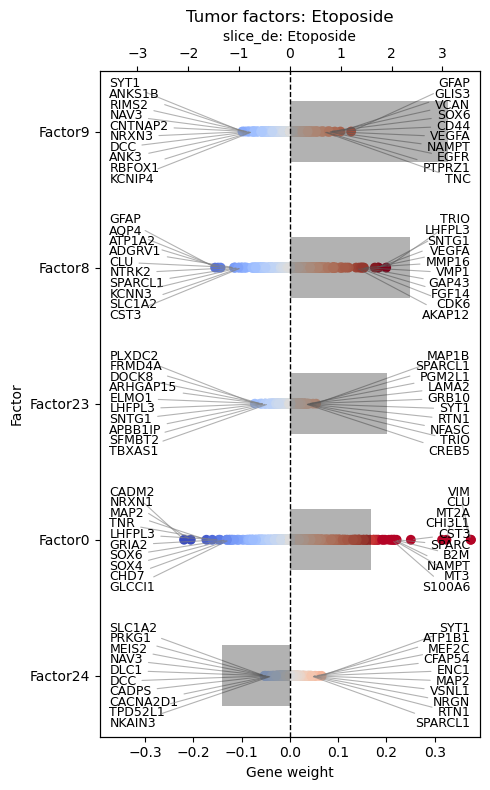

(<Figure size 500x800 with 2 Axes>,
 (<Axes: title={'center': 'Tumor factors: Etoposide'}, xlabel='Gene weight', ylabel='Factor'>,
  <Axes: xlabel='slice_de: Etoposide'>),
 factor
 Factor9|Tumor     3.117795
 Factor8|Tumor     2.354254
 Factor23|Tumor    1.908854
 Factor0|Tumor     1.590712
 Factor24|Tumor   -1.336198
 Name: Etoposide, dtype: float32)

In [8]:
scfo.plot_factor_effect_sizes(
    ontology=ontology,
    modality='slice_de',
    group = 'Etoposide',
    cell_type='Tumor'
)

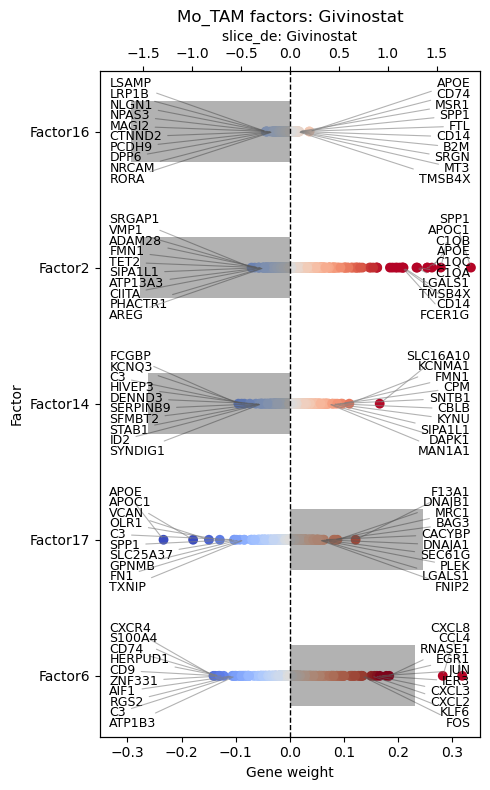

(<Figure size 500x800 with 2 Axes>,
 (<Axes: title={'center': 'Mo_TAM factors: Givinostat'}, xlabel='Gene weight', ylabel='Factor'>,
  <Axes: xlabel='slice_de: Givinostat'>),
 factor
 Factor16|Mo_TAM   -1.617387
 Factor2|Mo_TAM    -1.532262
 Factor14|Mo_TAM   -1.447136
 Factor17|Mo_TAM    1.362010
 Factor6|Mo_TAM     1.276885
 Name: Givinostat, dtype: float32)

In [9]:
scfo.plot_factor_effect_sizes(
    ontology=ontology,
    modality='slice_de',
    group = 'Givinostat',
    cell_type='Mo_TAM'
)

### Amazing! We can now interrogate treatment effects using our scFO object.